# pff analysis
Make sky maps and calculate significance for one source over multiple nights of pff data.

Processes each night's raw data into per-telescope cleaned images and Hillas parameters
(`heap.events.process_night()` -> `heap.process_dataset.process_dataset()`), builds array events from timing
coincidences (`heap.events`), reconstructs arrival directions (`heap.reconstruction`), and runs the on/off
analysis (`heap.significance`) for all nights combined and night by night.

Settings that change the results (data, telescopes, event building, cuts) come from a config in `configs/`
(see `configs/crab.yaml` and `heap.config`); run-time toggles and plotting settings are below.

# Imports

In [1]:
# imports
import re
import sys
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy.stats import norm

from heap import events as ev
from heap import significance as sg
from heap.config import load_analysis_config
from heap.parameterize import TAB10_COLORS
from heap.reconstruction import reconstruct_directions
from heap.sources import SOURCES

# Globals

In [2]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

# data
RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"]
SOURCE_POSITION = SOURCES.get(SOURCE) # on region center; None uses the median pointing
DATES = cfg["source"]["dates"]
POINTING_OVERRIDES = cfg["source"]["pointing_overrides"]
REPROCESS = False # rerun image processing for nights that already have output

# telescopes and image processing
TELESCOPE_MODULES = cfg["telescopes"]
DATA_PRODUCT = cfg["pipeline"]["data_product"]
IMAGE_THRESHOLD = cfg["pipeline"]["image_threshold"]
BORDER_THRESHOLD = cfg["pipeline"]["border_threshold"]
KEEP_BRIGHTEST_ISLAND = cfg["pipeline"]["keep_brightest_island"]

# event building
REFERENCE = cfg["events"]["reference"]
COINC_WINDOW = cfg["events"]["coinc_window"]
PLOT_TIMING = False # show each telescope's timing correction against its run's timing reference
ROTATE_POSTFLIP = cfg["events"]["rotate_postflip"]
REL_TEL_EFFICIENCY = cfg["events"]["rel_tel_efficiency"]
POINTING_CORRECTIONS = cfg["events"]["pointing_corrections"]

In [3]:
# analysis cuts
MIN_NPIX = cfg["cuts"]["min_npix"]
MIN_TEL = cfg["cuts"]["min_tel"]
TELESCOPES = cfg["cuts"]["telescopes"]
THETA = cfg["cuts"]["theta"]
MAX_DISTANCE = cfg["cuts"]["max_distance"]
OFF_REGIONS = cfg["cuts"]["off_regions"]
IMAGE_CUTS = cfg["cuts"]["image_cuts"]
POSITION_CUTS = cfg["cuts"]["position_cuts"]

# plotting
PLOT_RADIUS = 2  # degrees from center; controls extent of all sky-position plots below
BIN_WIDTH = 0.05
CBAR_VMIN = -5  # fixed range for the significance map and significance distribution
CBAR_VMAX = 5
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

# Data files

In [4]:
if DATES is None:
    DATES = sorted(p.name for p in RAW_DATA_DIR.iterdir() if p.is_dir() and re.fullmatch(r"\d{8}", p.name))
DATES

['20260917', '20260918', '20260922']

## Image processing
Pedestals, gain, cleaning, and Hillas parameters for every source each night (see
`heap.process_dataset.process_dataset()`). Nights already processed are skipped unless `REPROCESS`.

In [5]:
for date in DATES:
    ev.process_night(
        RAW_DATA_DIR / date, OUTPUT_DIR, date, TELESCOPE_MODULES, data_product=DATA_PRODUCT,
        image_threshold=IMAGE_THRESHOLD, border_threshold=BORDER_THRESHOLD, keep_brightest_island=KEEP_BRIGHTEST_ISLAND,
        reprocess=REPROCESS,
    )

dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T09:55:29Z.runtype_ph.pffd/start_2026-09-22T09:56:27Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  2358
Number of Events with package loss:  2358  ( 100.0 %)
     no frames left after the packet-loss cut, skipping this file
  Skipping NGC 1275: no usable Gattini frames (all cut for packet loss/spikes)
dp_ph1024*module_254: 1 files found
  -> /home/nkorzoun/research/PANOSETI/data/20260922/pff/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/obs_Palomar.start_2026-09-22T10:36:38Z.runtype_ph.pffd/start_2026-09-22T10:37:38Z.dp_ph1024.bpp_2.module_254.seqno_0.pff
Data read in, number of events:  3219
Number of Events with package loss:  3219  ( 100.0 %)
     no frames left after the packet-loss cut, skipping this file
  Skipping Crab: no usable Gattini frames (all cut for packet loss/sp

## Build events
Flip side comes from hk.pff (`heap.events.source_runs()`). Each telescope's timestamps are corrected against
`REFERENCE` before matching (plotted if `PLOT_TIMING`).

In [6]:
buffer=0
dfs=[]
pointings={} # each run's array pointing
for date in DATES:
    print(date)
    temp, night_pointings = ev.build_array_events(
        OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES, REFERENCE,
        window=COINC_WINDOW, rotate_postflip=ROTATE_POSTFLIP,
        rel_tel_efficiency=REL_TEL_EFFICIENCY, pointing_corrections=POINTING_CORRECTIONS,
        pointing_overrides=POINTING_OVERRIDES, plotting=PLOT_TIMING,
    )
    pointings |= night_pointings
    if temp is None or len(temp) == 0:
        print(f"{date}: no {SOURCE} events")
        continue
    temp["Event"]=temp["Event"]+buffer
    buffer=temp["Event"].max()+1
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

20260917
obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd, 09:51:23-10:51:23 UTC: timing reference Winter; Heli 3357, Fern 3076, Winter 3972, Gattini 3189 images
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  6e-05 s, std= 5e-05 s
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  7e-05 s, std= 5e-05 s
Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  0.00036 s, std= 0.00035 s
Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Heli-Fern within 0.001s: 1612/3353 Heli events (48.1%) and 1612/3076 Fern events (52.4%) coincident, 1614 pairs
Heli-Winter within 0.001s: 1481/3353 Heli events (44.2%) and 1483/3972 Winter events (37.3%) coincident, 1484 pairs
Heli-Gattini within 0.001s: 216/3353 He

In [7]:
df.describe()

,Event,ImageIndex,Timestamp,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha,x_shift,y_shift
count,43041.000000,43041.000000,4.304100e+04,42468.000000,42468.000000,42468.000000,43041.000000,43041.000000,42468.000000,42468.000000,42468.000000,42468.000000,42468.000000,42468.000000,42468.000000
mean,8838.914245,6050.149044,1.789821e+09,0.009637,-0.107924,181.120262,3732.589140,25.981436,0.517614,0.257526,2.374668,3.698416,44.654603,0.000720,0.006164
std,5212.110795,3888.174282,1.907827e+05,2.761130,2.796959,103.693868,8001.750453,24.409935,0.226745,0.084020,1.519194,1.334938,26.014869,0.040242,0.034311
min,0.000000,0.000000,1.789639e+09,-4.876521,-4.820627,0.000106,0.000000,0.000000,0.097342,0.000000,0.000000,0.031887,0.000000,-0.082598,-0.048441
25%,4259.000000,2685.000000,1.789645e+09,-2.362298,-2.591461,90.259656,822.122958,12.000000,0.357450,0.206905,1.052315,2.747085,21.927674,-0.033962,-0.011456
50%,8759.000000,5747.000000,1.789731e+09,0.016375,-0.280821,182.805130,1689.665780,20.000000,0.467911,0.254586,2.232809,3.875750,45.144896,-0.000601,-0.005780
75%,13377.000000,9060.000000,1.790075e+09,2.363055,2.292333,270.000835,3661.540521,33.000000,0.628212,0.302441,3.600441,4.680695,66.829517,0.034906,0.028345
max,18076.000000,16821.000000,1.790079e+09,4.857019,4.891165,359.992383,305865.879437,862.000000,2.806017,2.716495,6.647977,6.739603,89.999514,0.084878,0.099177


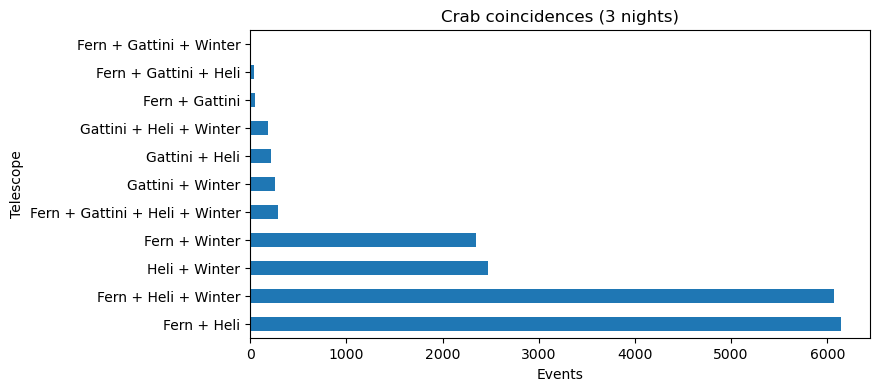

Telescope
Fern + Heli                       6139
Fern + Heli + Winter              6072
Heli + Winter                     2471
Fern + Winter                     2346
Fern + Gattini + Heli + Winter     292
Gattini + Winter                   260
Gattini + Heli                     214
Gattini + Heli + Winter            182
Fern + Gattini                      52
Fern + Gattini + Heli               38
Fern + Gattini + Winter             11
Name: count, dtype: int64

In [8]:
# events per telescope combination
combos = df.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t))).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
combos.plot.barh(ax=ax)
ax.set_xlabel("Events")
ax.set_title(f"{SOURCE} coincidences ({df.Date.nunique()} nights)")
plt.show()
combos

## Cleaning data

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


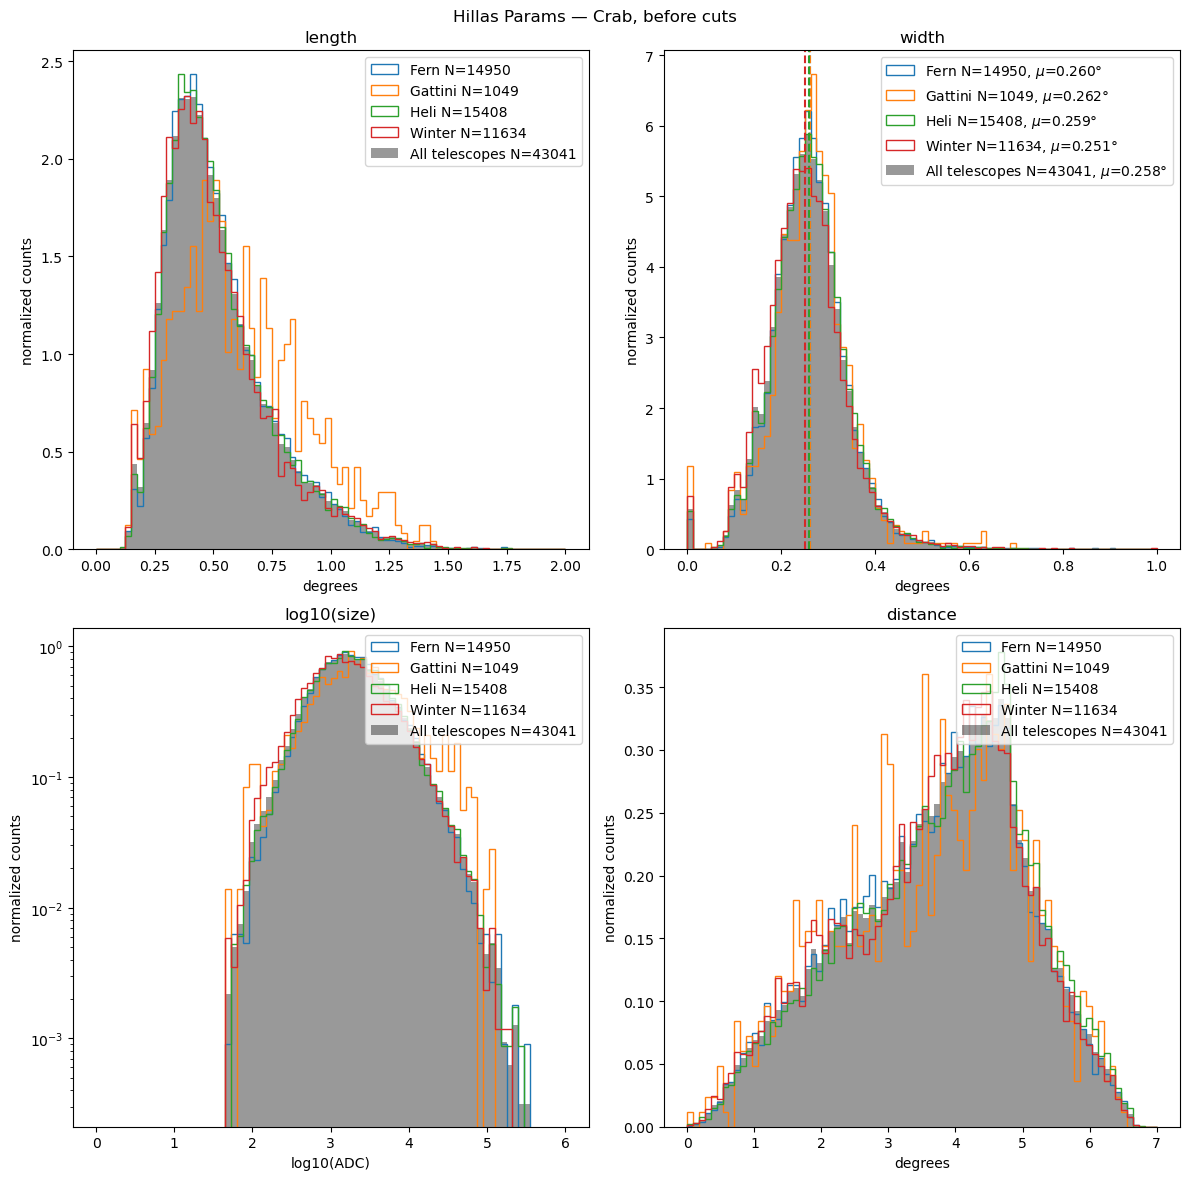

In [9]:
# image parameters before cuts
ev.plot_hillas(df, f"Hillas Params — {SOURCE}, before cuts", colors=COLORS)
plt.show()

In [10]:
array = ev.apply_cuts(df, min_tel=MIN_TEL, min_npix=MIN_NPIX, telescopes=TELESCOPES, cuts=IMAGE_CUTS)
array.head()

,Event,Date,Run,ImageIndex,Telescope,Timestamp,FlipSide,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha,x_shift,y_shift
0,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,0,Fern,1.789639e+09,preflip,-3.564270,3.899211,128.674148,2214.582265,20,0.411947,0.273624,0.312486,5.286038,3.389037,-0.023538,-0.025763
1,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,4,Heli,1.789639e+09,preflip,-3.035369,3.800611,150.106281,2348.941153,17,0.399190,0.210049,1.737991,4.849050,21.003127,0.023642,0.038200
2,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2,Winter,1.789639e+09,preflip,-2.723438,3.214353,75.244972,2002.456139,14,0.304188,0.238010,3.454327,4.218060,54.978573,0.000495,-0.006239
3,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,1,Fern,1.789639e+09,preflip,-1.328098,-4.284919,284.153728,1814.154079,18,0.567324,0.210577,2.307139,4.455046,31.189554,-0.022255,-0.025552
5,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Winter,1.789639e+09,preflip,-0.545763,-4.274302,273.214891,1009.159295,16,0.449678,0.259498,0.784728,4.302852,10.508069,0.000448,-0.006260


In [11]:
array.describe()

,Event,ImageIndex,Timestamp,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha,x_shift,y_shift
count,30750.000000,30750.000000,3.075000e+04,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000,30750.000000
mean,8599.421821,5774.389561,1.789814e+09,0.112918,-0.094196,180.537075,2117.191859,18.736488,0.468575,0.225079,2.392855,3.751434,44.227998,0.000342,0.005815
std,5296.548973,3870.788599,1.894950e+05,2.793006,2.848222,104.496957,2869.918003,11.143653,0.194971,0.050010,1.547803,1.364756,26.037558,0.039750,0.033890
min,0.000000,0.000000,1.789639e+09,-4.850768,-4.802496,0.005878,77.067131,3.000000,0.127674,0.046006,0.000045,0.031887,0.011845,-0.082598,-0.048441
25%,3914.250000,2406.000000,1.789645e+09,-2.244241,-2.625407,88.808898,704.564476,11.000000,0.331889,0.193086,1.034182,2.772950,21.448500,-0.033854,-0.011457
50%,8420.500000,5382.000000,1.789731e+09,0.270629,-0.274908,182.081084,1289.079585,16.000000,0.423168,0.232780,2.237062,3.949880,44.525724,-0.000599,-0.005837
75%,13139.750000,8765.000000,1.790075e+09,2.512986,2.382136,270.370719,2414.166458,24.000000,0.561121,0.264863,3.660632,4.752800,66.357174,0.034637,0.028345
max,18076.000000,16821.000000,1.790079e+09,4.857019,4.854760,359.991183,83353.540405,93.000000,2.074557,0.307883,6.647977,6.677195,89.999514,0.084878,0.099177


In [12]:
array.Event.nunique()

16462

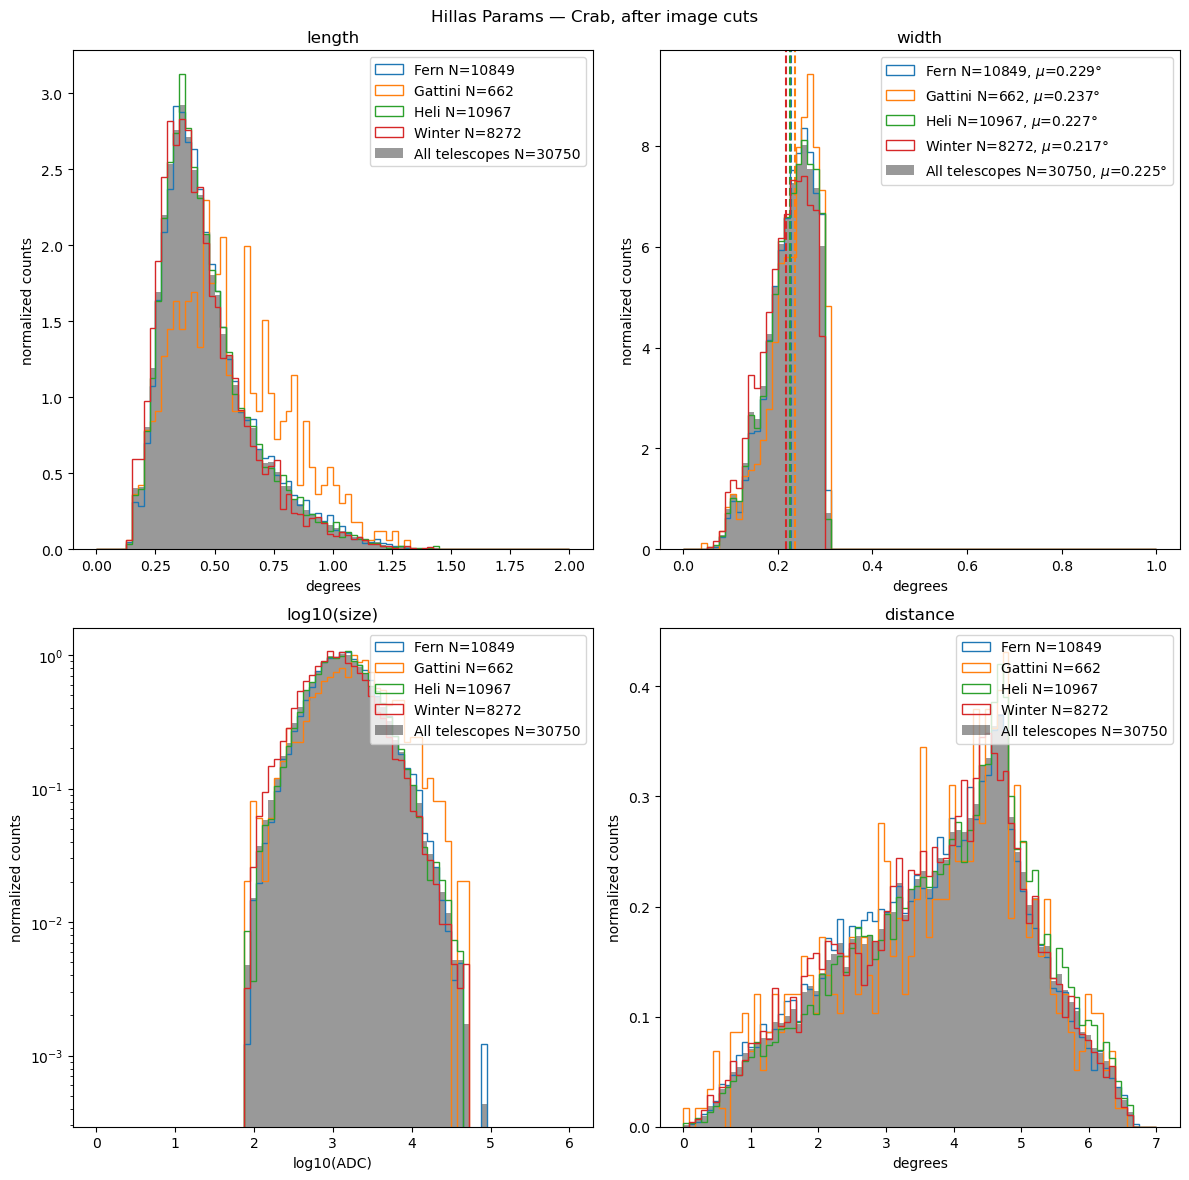

In [13]:
# image parameters after image cuts
ev.plot_hillas(array, f"Hillas Params — {SOURCE}, after image cuts", colors=COLORS)
plt.show()

# Arrival Directions

In [14]:
directions = reconstruct_directions(array)
directions.describe()

,Event,Xoffset,Yoffset
count,11945.000000,11945.000000,11945.000000
mean,8585.692005,0.467540,-0.084592
std,5300.679054,88.370912,16.228027
min,0.000000,-2486.789504,-813.215821
25%,3889.000000,-2.356404,-2.711742
50%,8378.000000,0.225416,-0.213970
75%,13071.000000,2.656500,2.483952
max,18076.000000,9097.902869,769.983837


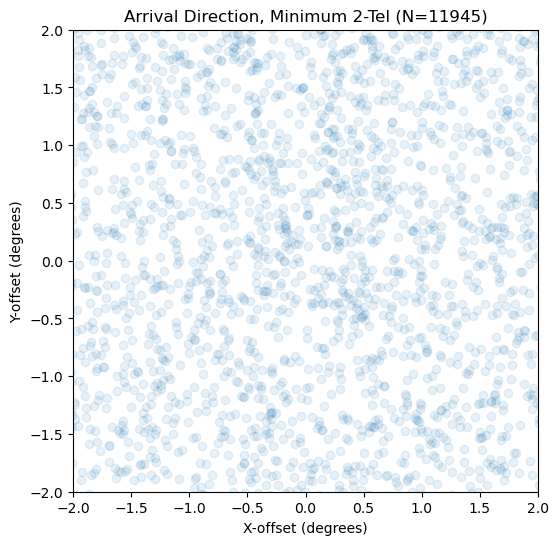

In [15]:
fig,axs = plt.subplots(figsize=(6,6))
plt.xlabel('X-offset (degrees)')
plt.ylabel('Y-offset (degrees)')
axs.set(xlim=[-PLOT_RADIUS,PLOT_RADIUS],ylim=[-PLOT_RADIUS,PLOT_RADIUS],title='Arrival Direction, Minimum {:.0f}-Tel (N={:.0f})'.format(MIN_TEL,len(directions)))
axs.scatter(directions.Xoffset,directions.Yoffset,alpha=0.1)

### Convert to RA/DEC

In [16]:
# pointing: each run's array pointing from build_array_events() (the mean of its telescopes' mount pointings while
# tracking, with POINTING_OVERRIDES for runs whose hk is missing or wrong), since wobble offsets differ run to run
unknown = sorted(set(POINTING_OVERRIDES) - set(directions.Run))
if unknown:
    raise ValueError(f"pointing_overrides for runs with no {SOURCE} events (check the run folder names): {unknown}")
pointings = {run: pointings[run] for run in directions.Run.unique()}
display(pd.DataFrame([(run, c.ra.deg, c.dec.deg, c.separation(SOURCE_POSITION).deg if SOURCE_POSITION is not None else np.nan)
              for run, c in pointings.items()], columns=["Run", "RA", "DEC", "offset from source"]))

# map center: the source, else the median run pointing
if SOURCE_POSITION is not None:
    center = SOURCE_POSITION
else:
    center = SkyCoord(np.median([c.ra.deg for c in pointings.values()]), np.median([c.dec.deg for c in pointings.values()]), unit=u.deg)

w = sg.make_wcs(center)
directions['RA'],directions['DEC'] = sg.camera_to_sky(directions, pointings)

,Run,RA,DEC,offset from source
0,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,83.635700,22.510903,0.493523
1,obs_Palomar.start_2026-09-17T11:08:55Z.runtype...,83.636327,22.491995,0.474620
2,obs_Palomar.start_2026-09-18T10:53:14Z.runtype...,83.640996,21.505786,0.511665
3,obs_Palomar.start_2026-09-22T10:36:38Z.runtype...,83.637216,22.505669,0.488300


In [17]:
w

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : np.float64(83.63241666666664) np.float64(22.01738888888889) 
CRPIX : np.float64(0.0) np.float64(0.0) 
PC1_1 PC1_2  : np.float64(1.0) np.float64(0.0) 
PC2_1 PC2_2  : np.float64(0.0) np.float64(1.0) 
CDELT : np.float64(1.0) np.float64(-1.0) 
NAXIS : 0  0

In [18]:
directions.describe()

,Event,Xoffset,Yoffset,RA,DEC
count,11945.000000,11945.000000,11945.000000,11945.000000,11945.000000
mean,8585.692005,0.467540,-0.084592,83.950927,22.223834
std,5300.679054,88.370912,16.228027,7.974320,4.457172
min,0.000000,-2486.789504,-813.215821,2.032076,-61.283102
25%,3889.000000,-2.356404,-2.711742,81.097017,19.711935
50%,8378.000000,0.225416,-0.213970,83.885411,22.346402
75%,13071.000000,2.656500,2.483952,86.503769,24.856748
max,18076.000000,9097.902869,769.983837,359.282121,82.957664


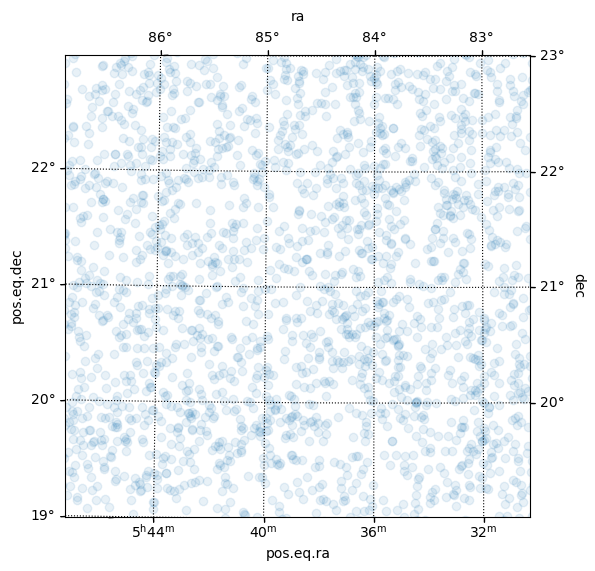

In [19]:
fig=plt.figure(figsize=(6,6))
ax = plt.subplot(projection=w)
ax.set_xlim(PLOT_RADIUS,-PLOT_RADIUS) # w's +x is east and +y south (see heap.significance.make_wcs); reversed for east left, north up
ax.set_ylim(PLOT_RADIUS,-PLOT_RADIUS)
ax.scatter(directions.RA,directions.DEC,transform=ax.get_transform('icrs'),alpha=0.1)

overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='black', ls='dotted')

## Event display
Run the cell below again for a different set of random images.

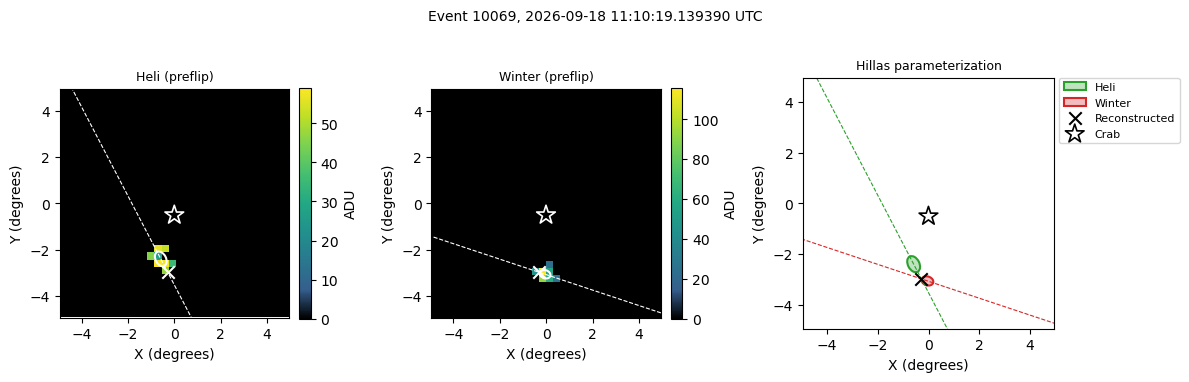

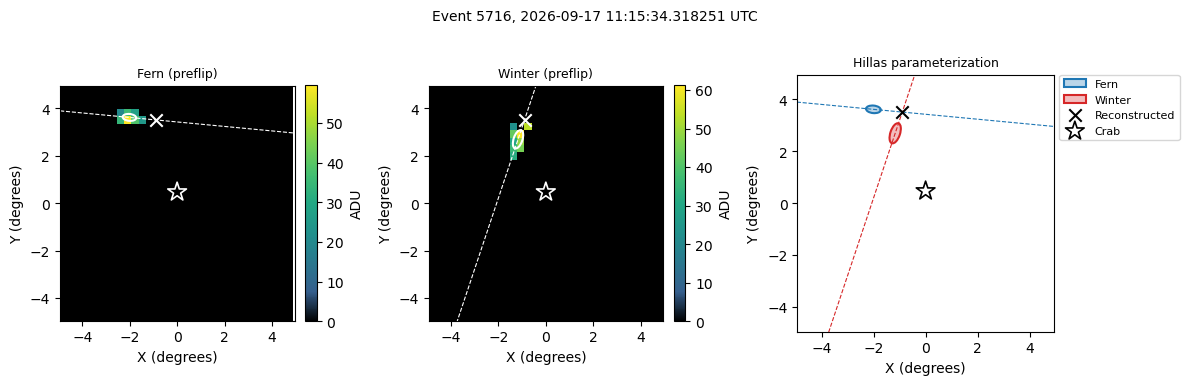

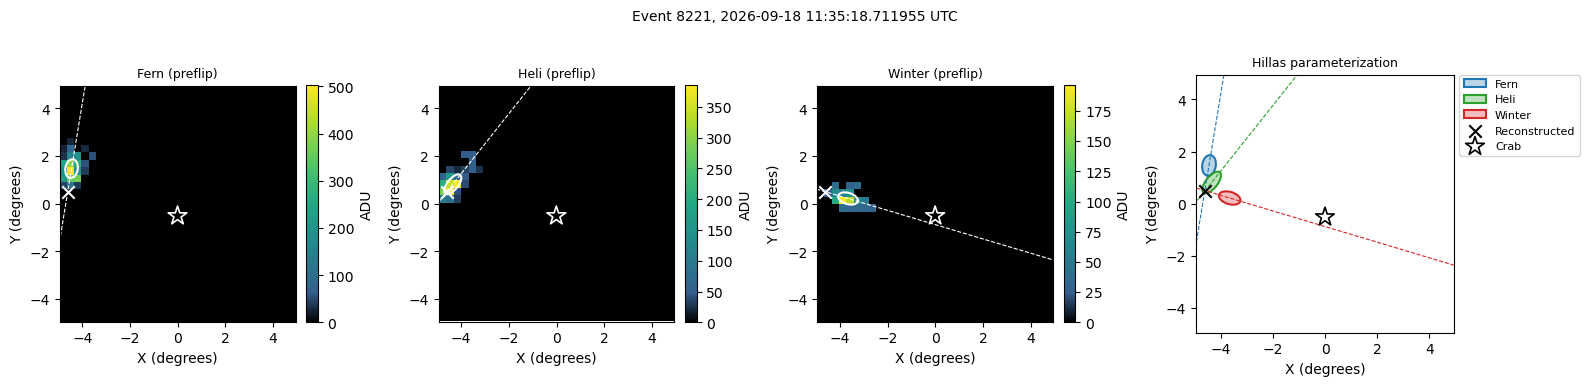

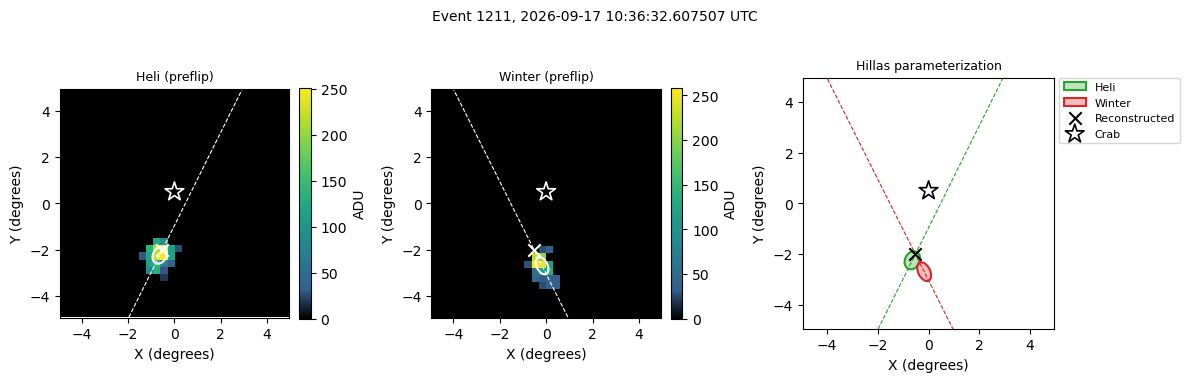

In [20]:
N_EVENTS = 4 # events to display, each with one panel per telescope image
for e in np.random.default_rng().choice(directions.Event, size=min(N_EVENTS, len(directions)), replace=False):
    ev.plot_event(
        array[array.Event == e], directions[directions.Event == e].iloc[0], OUTPUT_DIR, SOURCE,
        source_position=SOURCE_POSITION, pointings=pointings, colors=COLORS,
        rotate_postflip=ROTATE_POSTFLIP,
    )
    plt.show()

# Counts Map

In [21]:
n_bins = int(2*PLOT_RADIUS / BIN_WIDTH)
bins_RA = np.linspace(center.ra.deg-PLOT_RADIUS, center.ra.deg+PLOT_RADIUS, n_bins)
bins_DEC = np.linspace(center.dec.deg-PLOT_RADIUS, center.dec.deg+PLOT_RADIUS, n_bins)

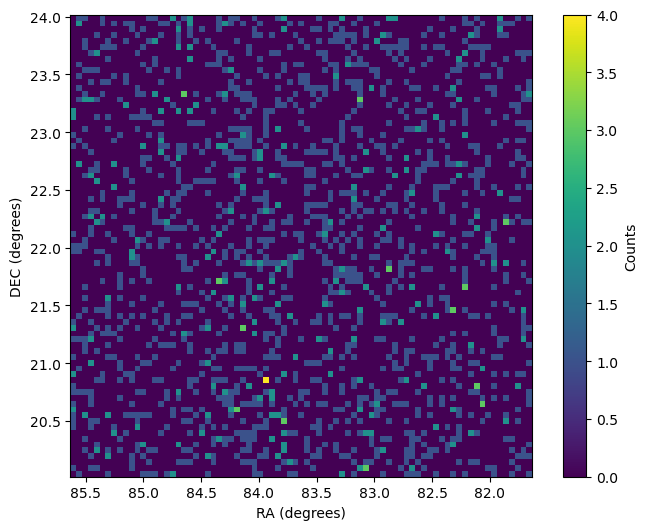

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(directions.RA, directions.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

plt.show()

## Define On/Off Regions

In [23]:
# test position defaults to the source (SOURCE_POSITION), else the median pointing
on_region = (center.ra.deg, center.dec.deg)

counter = sg.OnOffCounter(directions, array, pointings, THETA, MAX_DISTANCE, off_method=OFF_REGIONS, position_cuts=POSITION_CUTS)

# for display only: off regions around the nominal wobble pointings (on region +-WOBBLE_OFFSET in Dec) of the wobbles
# observed, since each run's own sit slightly apart (mount pointing scatter); counting uses each run's own
WOBBLE_OFFSET = 0.5 # deg
wobbles = sorted({np.sign(c.dec.deg - center.dec.deg) for c in pointings.values()})
nominal_pointings = [SkyCoord(center.ra, center.dec + s*WOBBLE_OFFSET*u.deg) for s in wobbles]
off_regions = counter.off_region_centers(*on_region, pointings=nominal_pointings) # in RA/DEC

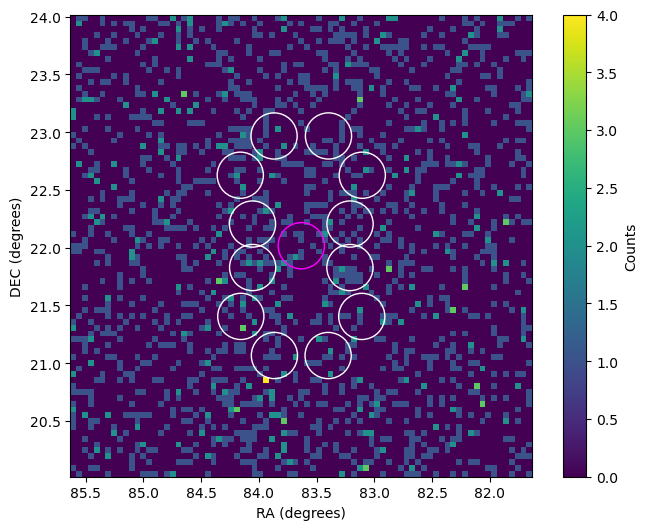

Number of off regions (nominal wobbles):  12


In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

hist = ax.hist2d(directions.RA, directions.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

for region in off_regions:
    circ = Circle(region, THETA, facecolor='None', edgecolor='white', lw=1)
    ax.add_patch(circ)
ax.add_patch(Circle(on_region,THETA,facecolor='None',edgecolor='magenta', lw=1))

plt.show()
print('Number of off regions (nominal wobbles): ',len(off_regions))

# Significance

Li and Ma (9):
$S=\frac{N_{on}-\alpha N_{off}}{\sqrt{\alpha(N_{on}+N_{off})}}$

`heap.significance.significance()` uses Equation 17

In [25]:
on, off = counter.events(*on_region)
N_on, N_off, alpha = counter.count(*on_region)
print(f"N_on = {N_on}, N_off = {N_off}, alpha = {alpha:.4f}")

# at test position only
sg.significance(N_on,N_off,alpha)

N_on = 12, N_off = 86, alpha = 0.1667


np.float64(-0.5896009147713218)

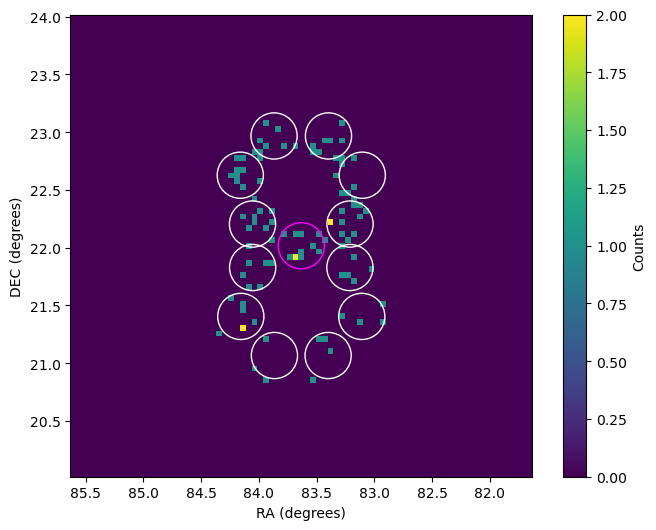

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
onoff=pd.concat([on,off])

hist = ax.hist2d(onoff.RA, onoff.DEC, bins=[bins_RA, bins_DEC], cmap='viridis')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.set_xlabel('RA (degrees)')
ax.set_ylabel('DEC (degrees)')

cbar = fig.colorbar(hist[3], ax=ax, label='Counts')

circ1 = Circle(on_region, THETA, facecolor='None', edgecolor='magenta', lw=1)
ax.add_patch(circ1)

for region in off_regions:
    circ = Circle((region[0],region[1]), THETA, facecolor='None', edgecolor='white', lw=1)
    ax.add_patch(circ)

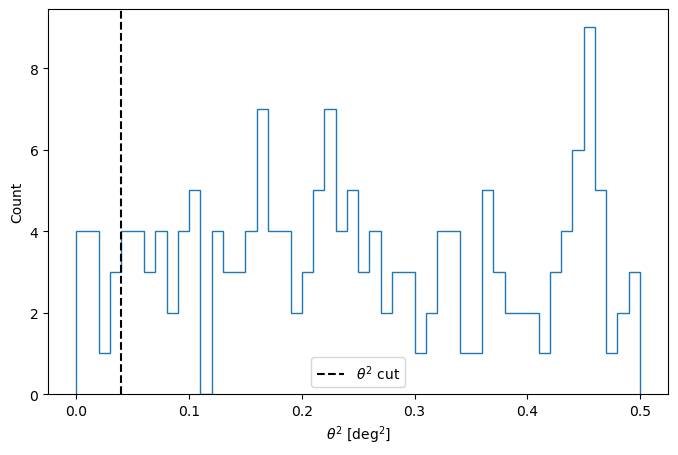

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

theta2 = counter.theta_square(*on_region).set_index('Event') # in each run's camera coordinates
directions['ThetaSquare'] = directions.Event.map(theta2.ThetaSquare)
directions['Distance'] = directions.Event.map(theta2.Distance)

directions_dcut = directions.dropna(subset=['Distance']) if MAX_DISTANCE is None else directions[directions.Distance < MAX_DISTANCE]

ax.hist(directions_dcut.ThetaSquare, bins=50, range=(0, 0.5), histtype='step')
ax.axvline(THETA**2, color='k', linestyle='--', label=r'$\theta^2$ cut')
ax.set_xlabel(r'$\theta^2$ [deg$^2$]')
ax.set_ylabel('Count')
ax.legend()
plt.show()

## Significance map

In [28]:
sig = sg.calc_sigmap(counter, bins_RA, bins_DEC, BIN_WIDTH)

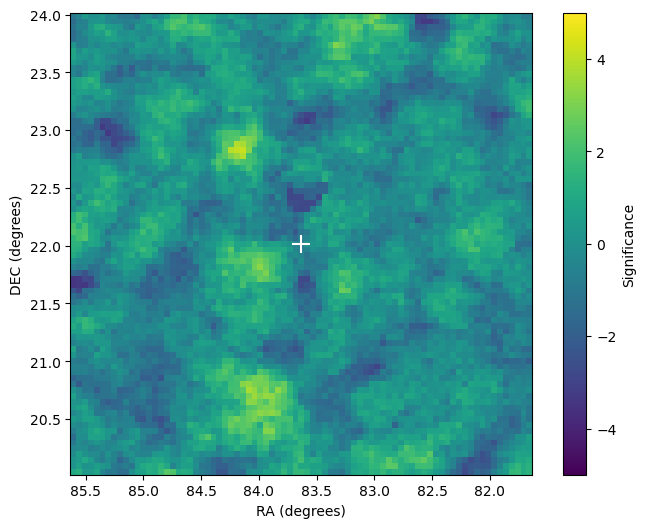

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
sg.plot_sky_map(ax, sig, sig.significance, 'Significance', bins_RA, bins_DEC, on_region, vmin=CBAR_VMIN, vmax=CBAR_VMAX)
plt.show()

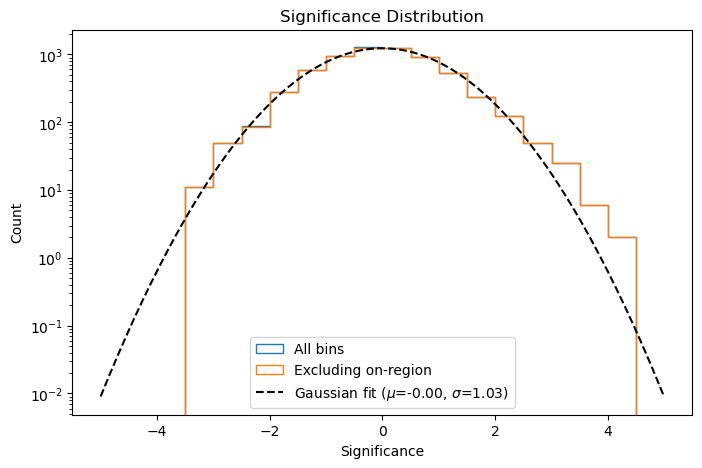

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

nbins=20
bins = np.linspace(CBAR_VMIN, CBAR_VMAX,nbins+1)

on_mask = np.hypot(sig.testPosX - on_region[0], sig.testPosY - on_region[1]) < THETA
sig_excl = sig[~on_mask]

ax.hist(sig.significance, bins=bins, histtype='step', label='All bins')
ax.hist(sig_excl.significance, bins=bins, histtype='step', label='Excluding on-region')

mu, std = norm.fit(sig_excl.significance)
x = np.linspace(CBAR_VMIN, CBAR_VMAX, 200)
bin_width = bins[1] - bins[0]
p = norm.pdf(x, mu, std) * len(sig_excl.significance) * bin_width
ax.plot(x, p, 'k--', label=f'Gaussian fit ($\\mu$={mu:.2f}, $\\sigma$={std:.2f})')

ax.set_yscale('log')
ax.set_xlabel('Significance')
ax.set_ylabel('Count')
ax.set_title('Significance Distribution')
ax.legend()

plt.show()

# On, Off, Alpha, and Excess Maps

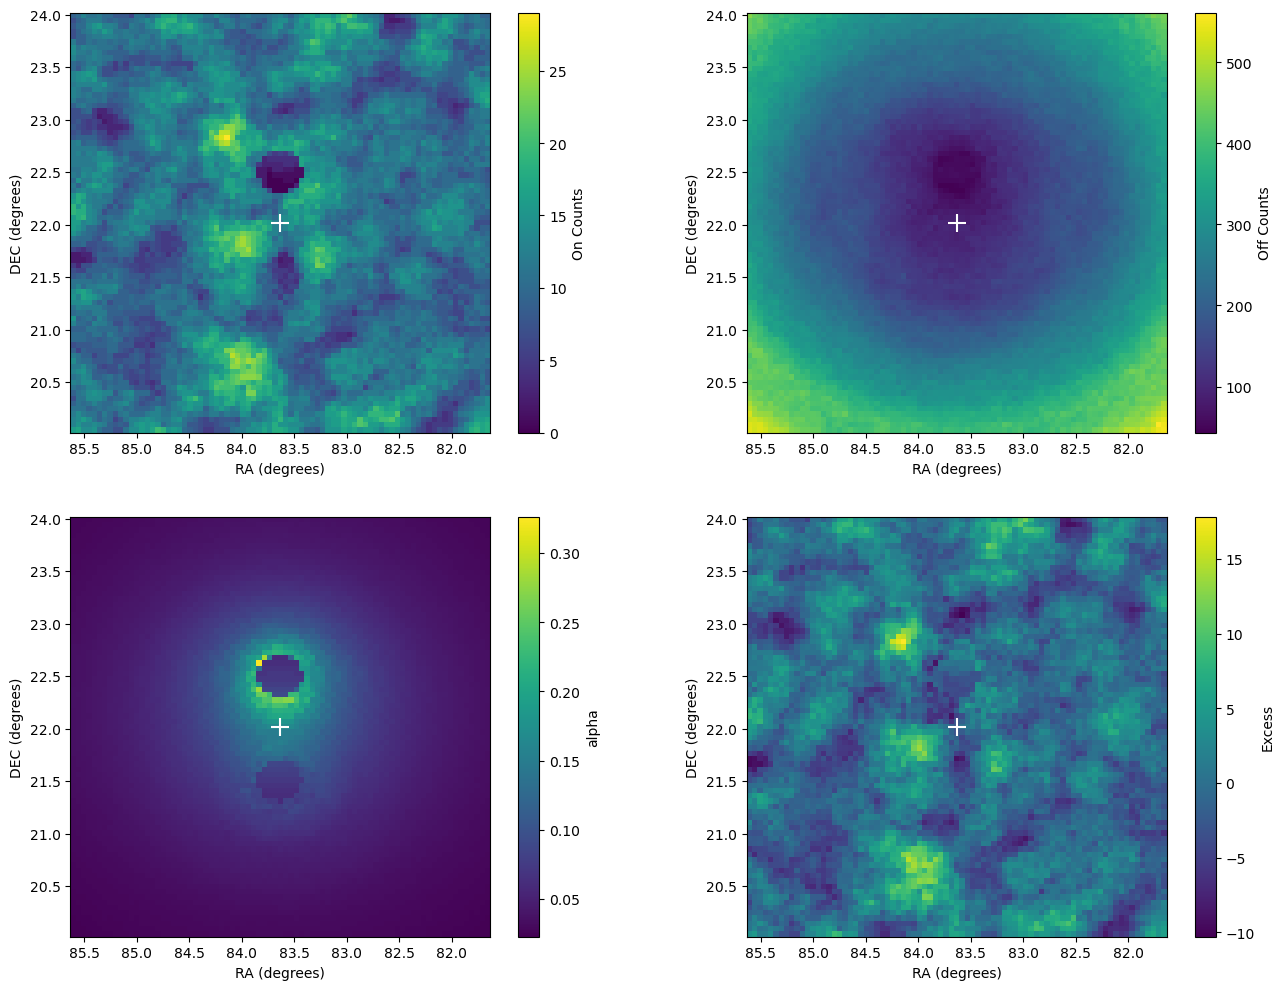

In [31]:
excess=sig.on-sig.alpha*sig.off

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
for ax, (weights, label) in zip(axs.flat, [(sig.on, 'On Counts'), (sig.off, 'Off Counts'), (sig.alpha, 'alpha'), (excess, 'Excess')]):
    sg.plot_sky_map(ax, sig, weights, label, bins_RA, bins_DEC, on_region)
plt.show()

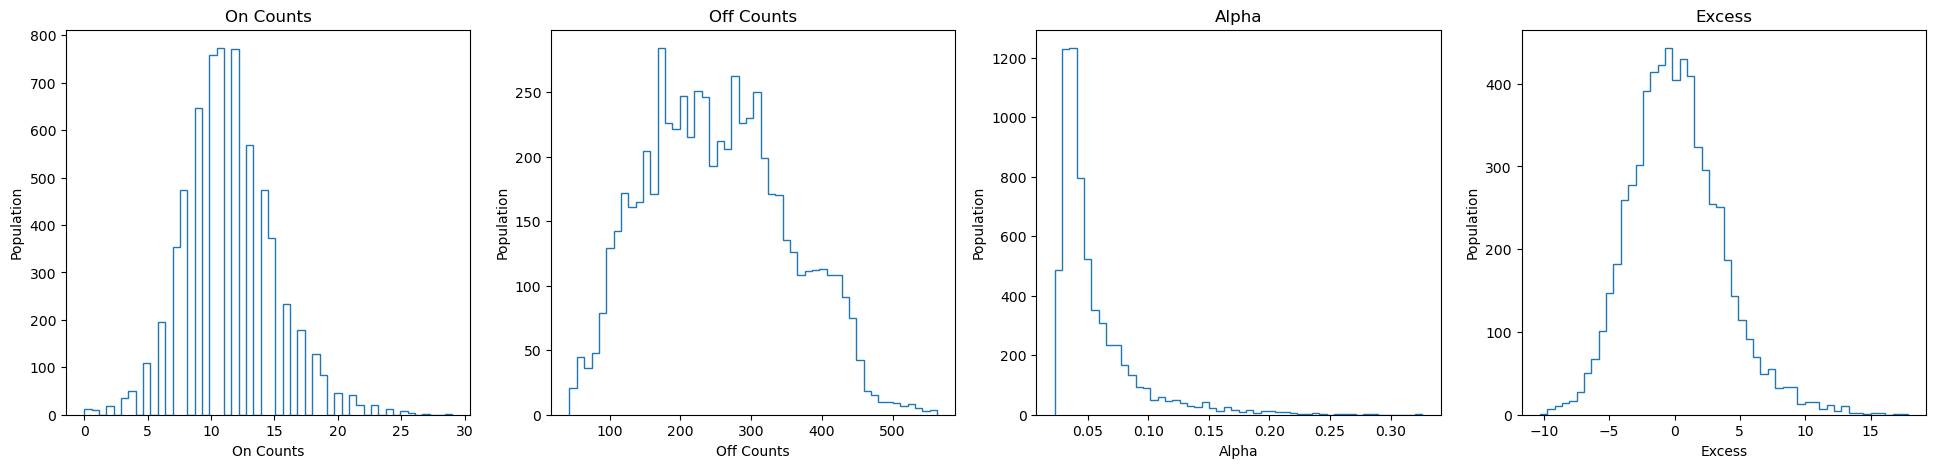

In [32]:
# other distributions
fig, axs = plt.subplots(1,4,figsize=(24, 5))
for ax, (values, title) in zip(axs, [(sig.on, 'On Counts'), (sig.off, 'Off Counts'), (sig.alpha, 'Alpha'), (excess, 'Excess')]):
    ax.hist(np.round(values, 10), bins=50, histtype='step') # rounding: alpha can differ only in the last bit, which np.histogram can't bin
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Population')

plt.show()

# Per night
On/off counts and alpha at the test position for each night, and significance accumulated night by night.

In [33]:
nights = counter.per_date(*on_region)
nights.insert(1, "Events", nights.Date.map(directions.Date.value_counts()))
nights["excess"] = nights.on - nights.alpha*nights.off
nights["significance"] = [sg.significance(n_on, n_off, a) for n_on, n_off, a in zip(nights.on, nights.off, nights.alpha)]
nights["cumulative significance"] = [sg.significance(*sg.combine_on_off(nights.iloc[:i+1])) for i in range(len(nights))]
nights

,Date,Events,on,off,alpha,excess,significance,cumulative significance
0,20260917,4490,5,26,0.166667,0.666667,0.288321,0.288321
1,20260918,3532,3,29,0.166667,-1.833333,-0.839008,-0.365892
2,20260922,3923,4,31,0.166667,-1.166667,-0.497816,-0.589601


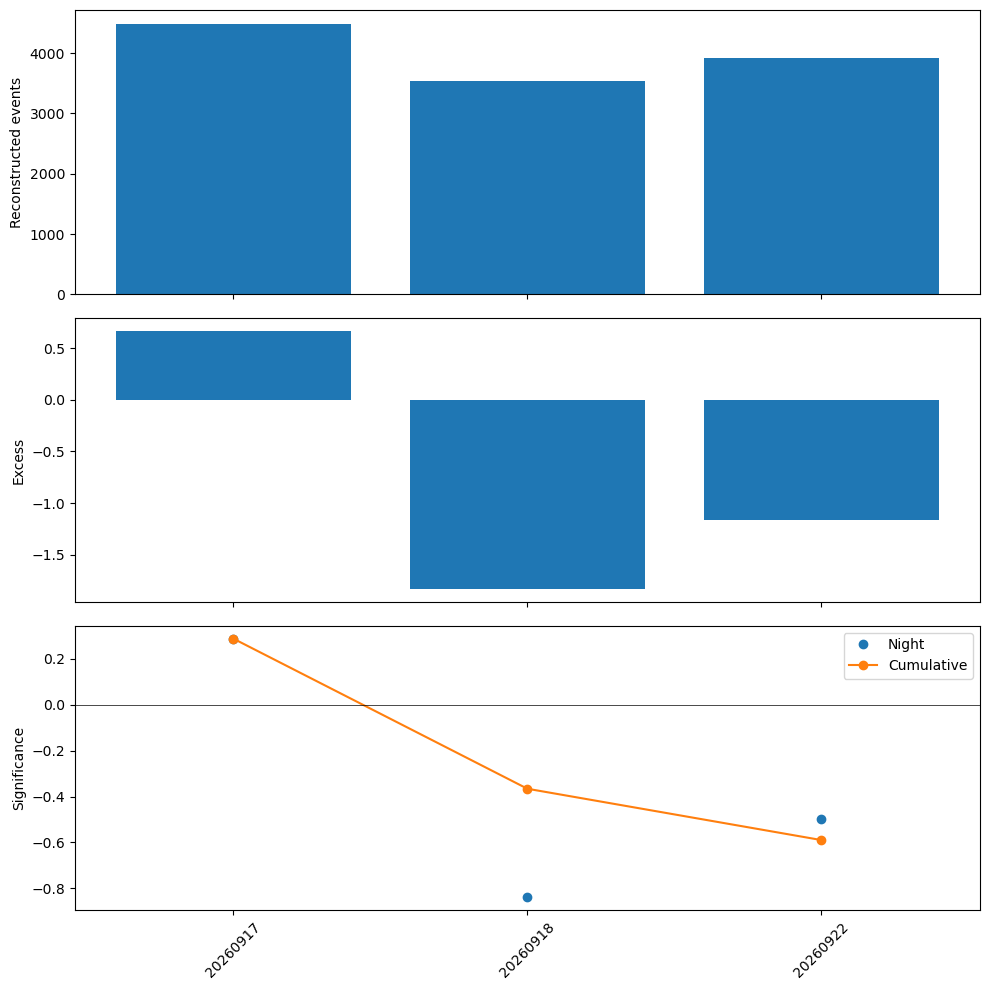

In [34]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axs[0].bar(nights.Date, nights.Events)
axs[0].set_ylabel("Reconstructed events")
axs[1].bar(nights.Date, nights.excess)
axs[1].set_ylabel("Excess")
axs[2].plot(nights.Date, nights.significance, "o", label="Night")
axs[2].plot(nights.Date, nights["cumulative significance"], "-o", label="Cumulative")
axs[2].axhline(0, color="k", lw=0.5)
axs[2].set_ylabel("Significance")
axs[2].legend()
axs[2].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()